In [1]:
import os
import torch
import pickle
from torch.utils.data import Dataset
import matplotlib.pyplot as plt
from rdkit import Chem
import json
import pandas as pd
import argparse
import sys
import random
import csv
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from rdkit.RDLogger import DisableLog
from CBTokenizer import CBTokenizer

# RDKit log banned
DisableLog('rdApp.*')


#set random seed
def set_seed(seed):
    """Set all possible random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# check molecule SMILES
def checkmol(pre_data):
    mols = pre_data.squence
    labels = pre_data.labels
    print('Original {} has {} data, start checking'.format(pre_data.args.dataset, len(mols)))

    valid_mols = []  
    valid_labels = []  

    for i in range(len(mols)):
        if mols[i] == "":
            continue
        mol = Chem.MolFromSmiles(mols[i])
        if mol is not None:
            # rdkit 检测分子正确性
            mol = Chem.MolToSmiles(mol, canonical=True, kekuleSmiles=False)
            valid_mols.append(mol)
            valid_labels.append(int(labels[i]))

    # 提取表达式和标签
    data = [[mol, label] for mol, label in zip(valid_mols, valid_labels)]
    print('Finish checking molecules, now {} has {} data'.format(pre_data.args.dataset, len(data)))
    return data




# split data
def data_split(post_data,args,status=False):
    '''status: get detail or not
    '''
    labels = [label for input_ids, attention_mask, label in post_data]

    train_val_data, test_data, train_val_labels, test_labels = train_test_split(
        post_data, labels, test_size=0.1, stratify=labels, random_state=args.seed
    )

    train_data, val_data, train_labels, val_labels = train_test_split(
        train_val_data, train_val_labels, test_size=1/9, stratify=train_val_labels, random_state=args.seed
    )
    
    if status == True:
        def count_class_distribution(data):
            counts = {0: 0, 1: 0}
            for _, label in data:
                counts[label] += 1
            return counts
        train_distribution = count_class_distribution(train_data)
        val_distribution = count_class_distribution(val_data)
        test_distribution = count_class_distribution(test_data)

        print("Train set class distribution:", train_distribution)
        print("Validation set class distribution:", val_distribution)
        print("Test set class distribution:", test_distribution)
    return train_data,val_data,test_data


# args to select dataset and seed
def create_args(dataset,name='modelname',seed=42):

    sys.argv = sys.argv[:1] + [arg for arg in sys.argv[1:] if not arg.startswith('--f=')]

    parser = argparse.ArgumentParser(description='Process some integers.')
    parser.add_argument('--dataset', type=str, default=dataset,
                        help='The name of the dataset (BBBP, HIV, BACE, Tox21, ClinTox)')
    parser.add_argument('--name', type=str, default=name,
                        help='The name of the dataset (BBBP, HIV, BACE, Tox21, ClinTox)')
    parser.add_argument('--seed', type=int, default=seed)
    args = parser.parse_args()
    return args

# process raw data (from MolR)
class PropertyPreData():
    def __init__(self, args):
        self.args = args
        self.path = './data/data_MoIR/' + args.dataset
        self.squence = []
        self.labels = []

    def process(self):
        print('processing ' + self.args.dataset+ ' dataset')
        with open(self.path + '.csv') as f:
            for idx, line in enumerate(f.readlines()):
                if idx == 0 or line == '\n':
                    continue
                items = line.strip().split(',')
                if self.args.dataset == 'BBBP':
                    smiles, label = items[-1], items[-2]
                    # the next line is to remove unnecessary hydrogen atoms that will cause discontinuous node labels
                    smiles = smiles.replace('([H])', '').replace('[H]', '')
                elif self.args.dataset == 'HIV':
                    smiles, label = items[0], items[-1]
                    smiles = smiles.replace('se', 'Se').replace('te', 'Te')
                elif self.args.dataset == 'BACE':
                    smiles, label = items[0], items[2]
                elif self.args.dataset == 'Tox21':
                    smiles, label = items[-1], items[11]
                    smiles = smiles.replace('se', 'Se')
                    if label == '':
                        continue
                elif self.args.dataset == 'ClinTox':
                    smiles, label = items[0], items[2]
                    smiles = smiles.replace('[H]', '')
                else:
                    raise ValueError('unknown dataset')
                self.squence.append(smiles)
                self.labels.append(float(label))


# convert SMILES to token
def preprocess_and_save_data(data, save_path, tokenizer):
    #difine length of tensor =  max(len(SMILES))+2
    max_smiles_length = max(len(smiles) for smiles, _ in data)
    maxlen = max_smiles_length + 2
    processed_data = []
    failed_data = []
    for smiles, label in data:
        try:
            encoded = tokenizer.encoder(smiles, alllen = maxlen, no0mode = False)
            processed_data.append((encoded["input_ids"], encoded["attention_mask"], label))
        except Exception as e:
            #print(f"Failed to encode SMILES: {smiles}, Error: {e}")
            failed_data.append((smiles, label))
    with open(save_path, 'wb') as f:
        pickle.dump(processed_data, f)
    print(f"maxlen : {maxlen}")
    print(f"final data {len(processed_data)}")
    print(f"Data saved to {save_path}")
    if failed_data:
        failed_save_path = save_path.replace('.pkl', '_failed.csv')
        with open(failed_save_path, 'w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(['SMILES', 'Label'])
            writer.writerows(failed_data)
        print(f"Failed data saved to {failed_save_path}")

/home/zhangyijian/.conda/envs/pytorch/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
tokenizer = CBTokenizer()
smiles = 'O1CC[C@@H](NC(=O)[C@@H](Cc2cc3cc(ccc3nc2N)-c2ccccc2C)C)CC1(C)C'
encoded = tokenizer.encoder(smiles, alllen = 100, no0mode = False)
encoded["input_ids"]

tensor([[  1, 120,  19,  ...,   0,   0,   0]])

## training

In [3]:
from CBmodel4prediction import *

def load_preprocessed_data(load_path):
    with open(load_path, 'rb') as f:
        data = pickle.load(f)
    print(f"Data loaded from {load_path}")
    return data

def train(args, pretrain_model='3520_molmodel.pt'):
    set_seed(args.seed)
    preprocess_save_path = f"./preprocessed_data/{args.dataset}.pkl"
    preprocessed_data = load_preprocessed_data(preprocess_save_path)

    train_data,val_data,test_data = data_split(preprocessed_data,args,status=False)
    #data = train_data + val_data
    
    print('train:val:test = {}:{}:{}'.format(len(train_data),len(val_data),len(test_data)))
   
    # 实例化新模型
    c = MolProperty(
        out_type=2,
        name=args.name,
        pre_model=pretrain_model,
        device="cuda:0",
        epoch_stop=5
    )
    print('start tarining!')
    #c.batchtrain(data, 50, int(len(data)*8/9), int(len(data)*1/9), te=0, batch_size = 4)
    c.batchtrain2(train_data,val_data, epoch=50, batch_size=4)
    print('finish tarining!!!')


def test(args):
    # 实例化新模型
    c = MolProperty(
        out_type=2,
        name=args.name,
        pre_model='model_1200',
        device="cuda:0"
    )
    set_seed(args.seed)

    preprocess_save_path = f"./preprocessed_data/{args.dataset}.pkl"
    preprocessed_data = load_preprocessed_data(preprocess_save_path)

    _, _, test_data = data_split(preprocessed_data, args)
    c.test(test_data)



[2026-03-13 17:59:41,189] [INFO] [real_accelerator.py:133:get_accelerator] Setting ds_accelerator to cuda (auto detect)


## ClinTox

Data loaded from ./preprocessed_data/ClinTox.pkl
train:val:test = 1180:148:148
Fine-tuned model loaded from checkpoints_test/ClinTox2025.pth
start tarining!
Epoch 0
Train Loss: 73.17472442984581, Train Acc: 0.923728813559322
Validation Acc: 0.9256756756756757, Val Count: 148
Model saved!
Epoch 1
Train Loss: 69.25684252381325, Train Acc: 0.923728813559322
Validation Acc: 0.9256756756756757, Val Count: 148
Epoch 2
Train Loss: 63.849790405482054, Train Acc: 0.9245762711864407
Validation Acc: 0.9256756756756757, Val Count: 148
Epoch 3
Train Loss: 60.10413282737136, Train Acc: 0.9245762711864407
Validation Acc: 0.9256756756756757, Val Count: 148
Epoch 4
Train Loss: 53.537909742444754, Train Acc: 0.9305084745762712
Validation Acc: 0.9324324324324325, Val Count: 148
Model saved!
Epoch 5
Train Loss: 49.74548455327749, Train Acc: 0.9305084745762712
Validation Acc: 0.9324324324324325, Val Count: 148
Epoch 6
Train Loss: 47.19096954166889, Train Acc: 0.9389830508474576
Validation Acc: 0.9324324324

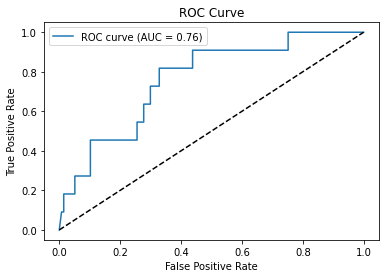

Test Accuracy: 0.9256756756756757, AUC: 0.7614465826144657
Data loaded from ./preprocessed_data/ClinTox.pkl
train:val:test = 1180:148:148
Fine-tuned model loaded from checkpoints_test/ClinTox2026.pth
start tarining!
Epoch 0
Train Loss: 60.059635523706675, Train Acc: 0.923728813559322
Validation Acc: 0.9324324324324325, Val Count: 148
Model saved!
Epoch 1
Train Loss: 55.19629134051502, Train Acc: 0.9288135593220339
Validation Acc: 0.918918918918919, Val Count: 148
Epoch 2
Train Loss: 48.099298514425755, Train Acc: 0.9372881355932203
Validation Acc: 0.918918918918919, Val Count: 148
Epoch 3
Train Loss: 45.08842802233994, Train Acc: 0.9423728813559322
Validation Acc: 0.8851351351351351, Val Count: 148
Epoch 4
Train Loss: 45.06945490837097, Train Acc: 0.9415254237288135
Validation Acc: 0.9054054054054054, Val Count: 148
Epoch 5
Train Loss: 41.53396068699658, Train Acc: 0.9440677966101695
Validation Acc: 0.9121621621621622, Val Count: 148
No improvement in the last 5 epochs. Training stoppe

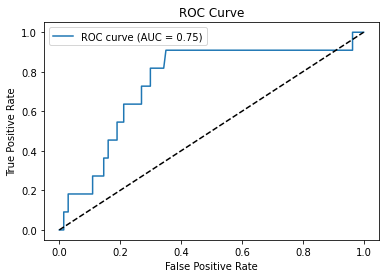

Test Accuracy: 0.9256756756756757, AUC: 0.7508294625082945
Data loaded from ./preprocessed_data/ClinTox.pkl
train:val:test = 1180:148:148
Fine-tuned model loaded from checkpoints_test/ClinTox2027.pth
start tarining!
Epoch 0
Train Loss: 72.46578681096435, Train Acc: 0.923728813559322
Validation Acc: 0.9256756756756757, Val Count: 148
Model saved!
Epoch 1
Train Loss: 69.43318603932858, Train Acc: 0.923728813559322
Validation Acc: 0.9256756756756757, Val Count: 148
Epoch 2
Train Loss: 66.47314961627126, Train Acc: 0.923728813559322
Validation Acc: 0.9256756756756757, Val Count: 148
Epoch 3
Train Loss: 60.19307991862297, Train Acc: 0.923728813559322
Validation Acc: 0.9256756756756757, Val Count: 148
Epoch 4
Train Loss: 59.94492028467357, Train Acc: 0.9254237288135593
Validation Acc: 0.9256756756756757, Val Count: 148
Epoch 5
Train Loss: 54.825448809191585, Train Acc: 0.9305084745762712
Validation Acc: 0.9324324324324325, Val Count: 148
Model saved!
Epoch 6
Train Loss: 51.963886896148324, T

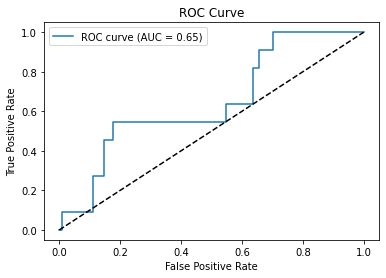

Test Accuracy: 0.9256756756756757, AUC: 0.648307896483079


In [8]:
for i in range(2025,2028):
    args = create_args('ClinTox','ClinTox'+str(i),i)
    train(args,pretrain_model='3520_molmodel.pt')
    test(args)

## BACE

Data loaded from ./preprocessed_data/BACE.pkl
train:val:test = 1209:152:152
Pre-trained model loaded from model/3520_molmodel.pt
start tarining!
Epoch 0
Train Loss: 193.12287643551826, Train Acc: 0.6344086021505376
Validation Acc: 0.7368421052631579, Val Count: 152
Model saved!
Epoch 1
Train Loss: 172.25373105704784, Train Acc: 0.7162944582299421
Validation Acc: 0.7171052631578947, Val Count: 152
Epoch 2
Train Loss: 157.8034457564354, Train Acc: 0.7468982630272953
Validation Acc: 0.7039473684210527, Val Count: 152
Epoch 3
Train Loss: 148.31080521643162, Train Acc: 0.7775020678246485
Validation Acc: 0.7105263157894737, Val Count: 152
Epoch 4
Train Loss: 139.15695501118898, Train Acc: 0.7956989247311828
Validation Acc: 0.7368421052631579, Val Count: 152
Epoch 5
Train Loss: 136.20308107882738, Train Acc: 0.7857733664185277
Validation Acc: 0.7631578947368421, Val Count: 152
Model saved!
Epoch 6
Train Loss: 126.45334360003471, Train Acc: 0.8163771712158809
Validation Acc: 0.756578947368421,

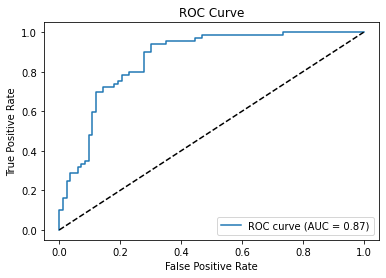

Test Accuracy: 0.7763157894736842, AUC: 0.8651999301554043
Data loaded from ./preprocessed_data/BACE.pkl
train:val:test = 1209:152:152
Pre-trained model loaded from model/3520_molmodel.pt
start tarining!
Epoch 0
Train Loss: 191.98968729376793, Train Acc: 0.6426799007444168
Validation Acc: 0.7368421052631579, Val Count: 152
Model saved!
Epoch 1
Train Loss: 175.02482084929943, Train Acc: 0.6898263027295285
Validation Acc: 0.7894736842105263, Val Count: 152
Model saved!
Epoch 2
Train Loss: 161.18863312900066, Train Acc: 0.7353184449958643
Validation Acc: 0.7960526315789473, Val Count: 152
Model saved!
Epoch 3
Train Loss: 151.83765669167042, Train Acc: 0.7576509511993383
Validation Acc: 0.7697368421052632, Val Count: 152
Epoch 4
Train Loss: 140.56477960199118, Train Acc: 0.7733664185277088
Validation Acc: 0.7697368421052632, Val Count: 152
Epoch 5
Train Loss: 135.67138908803463, Train Acc: 0.7849462365591398
Validation Acc: 0.8289473684210527, Val Count: 152
Model saved!
Epoch 6
Train Loss

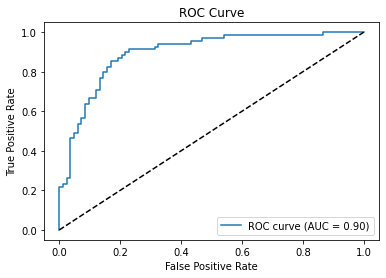

Test Accuracy: 0.8289473684210527, AUC: 0.895233106338397
Data loaded from ./preprocessed_data/BACE.pkl
train:val:test = 1209:152:152
Pre-trained model loaded from model/3520_molmodel.pt
start tarining!
Epoch 0
Train Loss: 193.32126805186272, Train Acc: 0.6468155500413565
Validation Acc: 0.6842105263157895, Val Count: 152
Model saved!
Epoch 1
Train Loss: 168.13670821487904, Train Acc: 0.7336641852770885
Validation Acc: 0.7302631578947368, Val Count: 152
Model saved!
Epoch 2
Train Loss: 152.73496633768082, Train Acc: 0.771712158808933
Validation Acc: 0.6973684210526315, Val Count: 152
Epoch 3
Train Loss: 146.09236308932304, Train Acc: 0.7907361455748553
Validation Acc: 0.7368421052631579, Val Count: 152
Model saved!
Epoch 4
Train Loss: 135.38206785172224, Train Acc: 0.8105872622001654
Validation Acc: 0.7105263157894737, Val Count: 152
Epoch 5
Train Loss: 129.7877675369382, Train Acc: 0.8196856906534326
Validation Acc: 0.7763157894736842, Val Count: 152
Model saved!
Epoch 6
Train Loss: 1

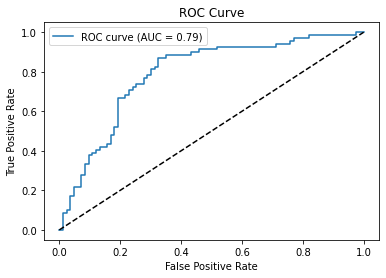

Test Accuracy: 0.7302631578947368, AUC: 0.7894185437401781


In [6]:
for i in range(2025,2028):
    args = create_args('BACE','BACE'+str(i),i)
    train(args,pretrain_model='3520_molmodel.pt')
    test(args)

## BBBP

Data loaded from ./preprocessed_data/BBBP.pkl
train:val:test = 1631:204:204
Pre-trained model loaded from model/3520_molmodel.pt
start tarining!
Epoch 0
Train Loss: 198.0647473335266, Train Acc: 0.7725321888412017
Validation Acc: 0.7892156862745098, Val Count: 204
Model saved!
Epoch 1
Train Loss: 159.61116860061884, Train Acc: 0.8430410790925812
Validation Acc: 0.8284313725490197, Val Count: 204
Model saved!
Epoch 2
Train Loss: 141.71503450348973, Train Acc: 0.8583690987124464
Validation Acc: 0.8627450980392157, Val Count: 204
Model saved!
Epoch 3
Train Loss: 131.29064210876822, Train Acc: 0.8583690987124464
Validation Acc: 0.8480392156862745, Val Count: 204
Epoch 4
Train Loss: 123.46631473302841, Train Acc: 0.8718577559779277
Validation Acc: 0.8578431372549019, Val Count: 204
Epoch 5
Train Loss: 116.01383036375046, Train Acc: 0.8816676885346413
Validation Acc: 0.8235294117647058, Val Count: 204
Epoch 6
Train Loss: 107.25576692447066, Train Acc: 0.8951563458001226
Validation Acc: 0.857

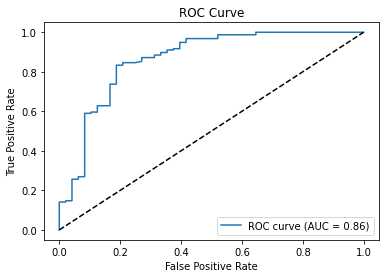

Test Accuracy: 0.8676470588235294, AUC: 0.8631810897435896
Data loaded from ./preprocessed_data/BBBP.pkl
train:val:test = 1631:204:204
Pre-trained model loaded from model/3520_molmodel.pt
start tarining!
Epoch 0
Train Loss: 195.2340418919921, Train Acc: 0.7847946045370938
Validation Acc: 0.8382352941176471, Val Count: 204
Model saved!
Epoch 1
Train Loss: 155.37451096624136, Train Acc: 0.8503985285101165
Validation Acc: 0.8529411764705882, Val Count: 204
Model saved!
Epoch 2
Train Loss: 143.23943887650967, Train Acc: 0.8577559779276518
Validation Acc: 0.8529411764705882, Val Count: 204
Epoch 3
Train Loss: 134.61005181446671, Train Acc: 0.8694052728387492
Validation Acc: 0.8627450980392157, Val Count: 204
Model saved!
Epoch 4
Train Loss: 126.33087350055575, Train Acc: 0.8755364806866953
Validation Acc: 0.8676470588235294, Val Count: 204
Model saved!
Epoch 5
Train Loss: 122.37327176332474, Train Acc: 0.8804414469650521
Validation Acc: 0.8774509803921569, Val Count: 204
Model saved!
Epoch 

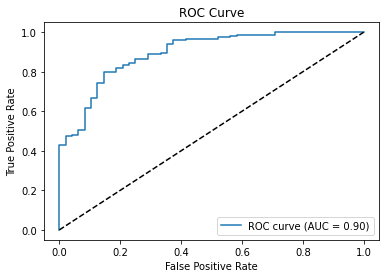

Test Accuracy: 0.8774509803921569, AUC: 0.8955662393162392
Data loaded from ./preprocessed_data/BBBP.pkl
train:val:test = 1631:204:204
Pre-trained model loaded from model/3520_molmodel.pt
start tarining!
Epoch 0
Train Loss: 199.04276037216187, Train Acc: 0.7670141017780503
Validation Acc: 0.7990196078431373, Val Count: 204
Model saved!
Epoch 1
Train Loss: 157.30934555083513, Train Acc: 0.841814837522992
Validation Acc: 0.8578431372549019, Val Count: 204
Model saved!
Epoch 2
Train Loss: 140.84088709950447, Train Acc: 0.8608215818516247
Validation Acc: 0.8431372549019608, Val Count: 204
Epoch 3
Train Loss: 134.7077413648367, Train Acc: 0.8663396689147762
Validation Acc: 0.8725490196078431, Val Count: 204
Model saved!
Epoch 4
Train Loss: 127.12301484495401, Train Acc: 0.8798283261802575
Validation Acc: 0.8725490196078431, Val Count: 204
Epoch 5
Train Loss: 120.29518651589751, Train Acc: 0.8871857755977928
Validation Acc: 0.8823529411764706, Val Count: 204
Model saved!
Epoch 6
Train Loss: 

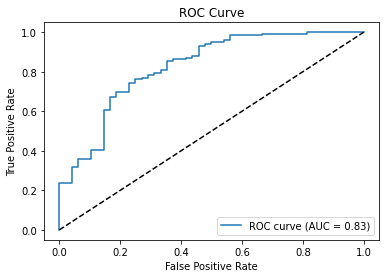

Test Accuracy: 0.7990196078431373, AUC: 0.8253205128205129


In [6]:
for i in range(2025,2028):
    args = create_args('BBBP','BBBP'+str(i),i)
    train(args,pretrain_model='3520_molmodel.pt')
    test(args)

## Tox21

Data loaded from ./preprocessed_data/Tox21.pkl
train:val:test = 5527:691:691
Pre-trained model loaded from model/3520_molmodel.pt
start tarining!
Epoch 0
Train Loss: 314.4198512621224, Train Acc: 0.9375791568662928
Validation Acc: 0.9377713458755427, Val Count: 691
Model saved!
Epoch 1
Train Loss: 287.8322998266667, Train Acc: 0.9375791568662928
Validation Acc: 0.9377713458755427, Val Count: 691
Epoch 2
Train Loss: 277.21814552508295, Train Acc: 0.9375791568662928
Validation Acc: 0.9377713458755427, Val Count: 691
Epoch 3
Train Loss: 265.2844668943435, Train Acc: 0.9375791568662928
Validation Acc: 0.9377713458755427, Val Count: 691
Epoch 4
Train Loss: 247.52181741595268, Train Acc: 0.9377600868463905
Validation Acc: 0.9377713458755427, Val Count: 691
Epoch 5
Train Loss: 234.83232080750167, Train Acc: 0.9406549665279537
Validation Acc: 0.9319826338639653, Val Count: 691
No improvement in the last 5 epochs. Training stopped.
finish tarining!!!
Fine-tuned model loaded from checkpoints_tes

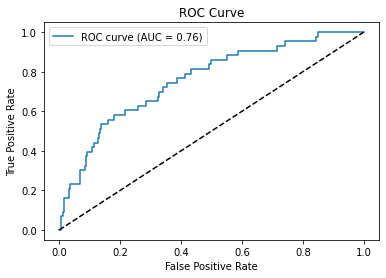

Test Accuracy: 0.9377713458755427, AUC: 0.7573930519666954
Data loaded from ./preprocessed_data/Tox21.pkl
train:val:test = 5527:691:691
Pre-trained model loaded from model/3520_molmodel.pt
start tarining!
Epoch 0
Train Loss: 312.55746177211404, Train Acc: 0.9375791568662928
Validation Acc: 0.9377713458755427, Val Count: 691
Model saved!
Epoch 1
Train Loss: 286.3827129751444, Train Acc: 0.9375791568662928
Validation Acc: 0.9377713458755427, Val Count: 691
Epoch 2
Train Loss: 277.5429629534483, Train Acc: 0.9375791568662928
Validation Acc: 0.9377713458755427, Val Count: 691
Epoch 3
Train Loss: 262.6670985426754, Train Acc: 0.9377600868463905
Validation Acc: 0.9377713458755427, Val Count: 691
Epoch 4
Train Loss: 251.81117526441813, Train Acc: 0.9392075266871721
Validation Acc: 0.9377713458755427, Val Count: 691
Epoch 5
Train Loss: 235.00844689644873, Train Acc: 0.9415596164284422
Validation Acc: 0.9377713458755427, Val Count: 691
No improvement in the last 5 epochs. Training stopped.
fini

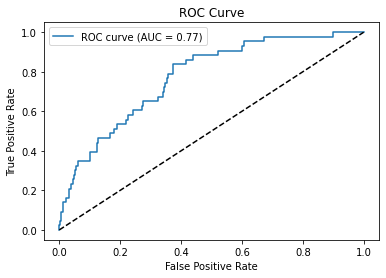

Test Accuracy: 0.9377713458755427, AUC: 0.7737582543784094
Data loaded from ./preprocessed_data/Tox21.pkl
train:val:test = 5527:691:691
Pre-trained model loaded from model/3520_molmodel.pt
start tarining!
Epoch 0
Train Loss: 308.3687023166567, Train Acc: 0.9375791568662928
Validation Acc: 0.9377713458755427, Val Count: 691
Model saved!
Epoch 1
Train Loss: 285.24192679673433, Train Acc: 0.9375791568662928
Validation Acc: 0.9377713458755427, Val Count: 691
Epoch 2
Train Loss: 276.2252206001431, Train Acc: 0.9375791568662928
Validation Acc: 0.9377713458755427, Val Count: 691
Epoch 3
Train Loss: 263.3568279230967, Train Acc: 0.9375791568662928
Validation Acc: 0.9377713458755427, Val Count: 691
Epoch 4
Train Loss: 248.97216108441353, Train Acc: 0.9375791568662928
Validation Acc: 0.9377713458755427, Val Count: 691
Epoch 5
Train Loss: 235.9511217372492, Train Acc: 0.9377600868463905
Validation Acc: 0.9377713458755427, Val Count: 691
No improvement in the last 5 epochs. Training stopped.
finis

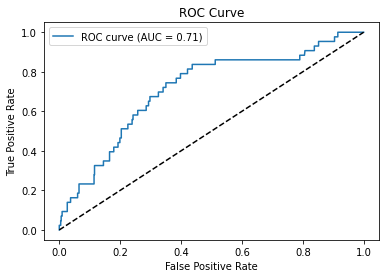

Test Accuracy: 0.9377713458755427, AUC: 0.7132680160780935


In [7]:
for i in range(2025,2028):
    args = create_args('Tox21','Tox21'+str(i),i)
    train(args, pretrain_model = '3520_molmodel.pt')
    test(args)

## HIV

Data loaded from ./preprocessed_data/HIV.pkl
train:val:test = 32898:4113:4113
Pre-trained model loaded from model/3520_molmodel.pt
start tarining!
Epoch 0
Train Loss: 1157.3936117123812, Train Acc: 0.9655602164265304
Validation Acc: 0.9659615852176027, Val Count: 4113
Model saved!
Epoch 1
Train Loss: 1053.9744621692225, Train Acc: 0.9664417289804851
Validation Acc: 0.9669341113542427, Val Count: 4113
Model saved!
Epoch 2
Train Loss: 985.7364360457286, Train Acc: 0.9677184023344885
Validation Acc: 0.9649890590809628, Val Count: 4113
Epoch 3
Train Loss: 928.4744702046737, Train Acc: 0.9689950756884917
Validation Acc: 0.9657184536834428, Val Count: 4113
Epoch 4
Train Loss: 897.0653050411493, Train Acc: 0.9699981761809229
Validation Acc: 0.9664478482859227, Val Count: 4113
Epoch 5
Train Loss: 860.4468881282955, Train Acc: 0.9716092163657365
Validation Acc: 0.9664478482859227, Val Count: 4113
Epoch 6
Train Loss: 820.4358062315732, Train Acc: 0.9724603319350721
Validation Acc: 0.962800875273

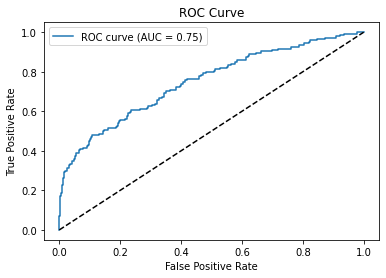

Test Accuracy: 0.9674203744225626, AUC: 0.7486212592032697
Data loaded from ./preprocessed_data/HIV.pkl
train:val:test = 32898:4113:4113
Pre-trained model loaded from model/3520_molmodel.pt
start tarining!
Epoch 0
Train Loss: 1159.2646794728935, Train Acc: 0.9660769651650556
Validation Acc: 0.9654753221492828, Val Count: 4113
Model saved!
Epoch 1
Train Loss: 1081.7097803438082, Train Acc: 0.966654507872819
Validation Acc: 0.9664478482859227, Val Count: 4113
Model saved!
Epoch 2
Train Loss: 1019.6383287971839, Train Acc: 0.9679311812268223
Validation Acc: 0.9652321906151228, Val Count: 4113
Epoch 3
Train Loss: 963.1651637339965, Train Acc: 0.9686911058423004
Validation Acc: 0.9674203744225626, Val Count: 4113
Model saved!
Epoch 4
Train Loss: 916.5531502878293, Train Acc: 0.9696942063347316
Validation Acc: 0.9669341113542427, Val Count: 4113
Epoch 5
Train Loss: 869.2446543285623, Train Acc: 0.9706973068271627
Validation Acc: 0.9693654266958425, Val Count: 4113
Model saved!
Epoch 6
Train 

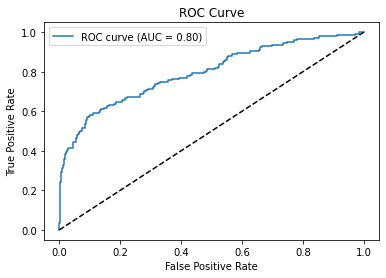

Test Accuracy: 0.9679066374908826, AUC: 0.7954074633968813
Data loaded from ./preprocessed_data/HIV.pkl
train:val:test = 32898:4113:4113
Pre-trained model loaded from model/3520_molmodel.pt
start tarining!
Epoch 0
Train Loss: 1162.1892152968794, Train Acc: 0.9652866435649583
Validation Acc: 0.9645027960126429, Val Count: 4113
Model saved!
Epoch 1
Train Loss: 1058.2050945246592, Train Acc: 0.9661073621496747
Validation Acc: 0.9662047167517627, Val Count: 4113
Model saved!
Epoch 2
Train Loss: 1002.8925336105749, Train Acc: 0.9671104626421059
Validation Acc: 0.9681497690250426, Val Count: 4113
Model saved!
Epoch 3
Train Loss: 953.1938867215067, Train Acc: 0.967384035503678
Validation Acc: 0.9696085582300025, Val Count: 4113
Model saved!
Epoch 4
Train Loss: 910.0057501662523, Train Acc: 0.9691774575962064
Validation Acc: 0.9691222951616825, Val Count: 4113
Epoch 5
Train Loss: 871.6176737090573, Train Acc: 0.9699981761809229
Validation Acc: 0.9713104789691223, Val Count: 4113
Model saved!
E

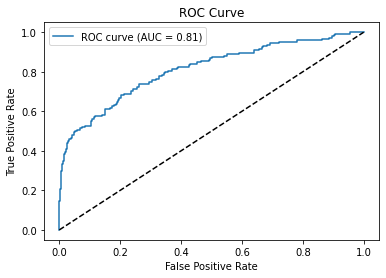

Test Accuracy: 0.9691222951616825, AUC: 0.8104668822261415


In [7]:
for i in range(2025,2028):
    args = create_args('HIV','HIV'+str(i),i)
    train(args,pretrain_model='3520_molmodel.pt')
    test(args)

## result

In [9]:
#  AUC 矩阵
auc_matrix = {
    'BACE': [0.86519,0.89523, 0.78941],
    'BBBP': [ 0.86318, 0.89556, 0.82532],
    'ClinTox': [0.76144, 0.75082,0.64830],
    'Tox21': [0.75739, 0.77375, 0.71326],
    'HIV': [0.74862,0.79540,0.81046]
}

# 计算每个数据集的均值和标准差
results = {}
for dataset, auc_values in auc_matrix.items():
    mean_auc = np.mean(auc_values)
    std_auc = np.std(auc_values)
    results[dataset] = {'mean': mean_auc, 'std': std_auc}

# 打印结果
for dataset, values in results.items():
    print(f"Dataset: {dataset}")
    print(f"  Mean AUC: {values['mean']:.4f}")
    print(f"  Std AUC: {values['std']:.4f}")

Dataset: BACE
  Mean AUC: 0.8499
  Std AUC: 0.0445
Dataset: BBBP
  Mean AUC: 0.8614
  Std AUC: 0.0287
Dataset: ClinTox
  Mean AUC: 0.7202
  Std AUC: 0.0510
Dataset: Tox21
  Mean AUC: 0.7481
  Std AUC: 0.0255
Dataset: HIV
  Mean AUC: 0.7848
  Std AUC: 0.0263
